# Model Training & Evaluation

This notebook walks through the modeling stage implemented in [`src/models/train_model.py`](../src/models/train_model.py) and [`src/models/evaluate_model.py`](../src/models/evaluate_model.py). Three classifiers — Logistic Regression, Random Forest, and XGBoost — are tuned with 5-fold stratified cross-validation inside an imbalanced-learn pipeline (preprocessing → SMOTE oversampling → classifier), scored on ROC-AUC. The full grid search is run by the pipeline script (`python -m src.models.train_model`); here we load the persisted results for review.

In [1]:
import sys
sys.path.append('..')

import json
import joblib
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import RocCurveDisplay, ConfusionMatrixDisplay, confusion_matrix, classification_report

from src.features.build_features import TARGET

artifact = joblib.load('../models/churn_model.joblib')
pipeline = artifact['pipeline']
print('Best model:', artifact['model_name'])
print('CV ROC-AUC:', round(artifact['cv_roc_auc'], 4))
print('Best hyperparameters:', artifact['best_params'])

Best model: xgboost
CV ROC-AUC: 0.8474
Best hyperparameters: {'clf__learning_rate': 0.05, 'clf__max_depth': 3, 'clf__n_estimators': 200}


## Model comparison

All three tuned models, ranked by cross-validated ROC-AUC:

In [2]:
comparison = pd.read_csv('../reports/model_comparison.csv')
comparison

,model,cv_roc_auc,best_params,train_seconds,accuracy,precision,recall,f1_score,roc_auc
0,xgboost,0.8474,"{""clf__learning_rate"": 0.05, ""clf__max_depth"":...",5.0,0.7922,0.5966,0.6640,0.6285,0.8414
1,logistic_regression,0.8453,"{""clf__C"": 1, ""clf__penalty"": ""l2"", ""clf__solv...",3.1,0.7495,0.5184,0.7581,0.6157,0.8395
2,random_forest,0.8447,"{""clf__max_depth"": 6, ""clf__min_samples_leaf"":...",16.5,0.7687,0.5456,0.7554,0.6336,0.8412


## Held-out test set performance

In [3]:
test_df = pd.read_csv('../data/processed/test.csv')
X_test, y_test = test_df.drop(columns=[TARGET]), test_df[TARGET]
y_pred = pipeline.predict(X_test)

print(classification_report(y_test, y_pred, target_names=['Retained', 'Churned']))

              precision    recall  f1-score   support

    Retained       0.87      0.84      0.86      1033
     Churned       0.60      0.66      0.63       372

    accuracy                           0.79      1405
   macro avg       0.74      0.75      0.74      1405
weighted avg       0.80      0.79      0.80      1405



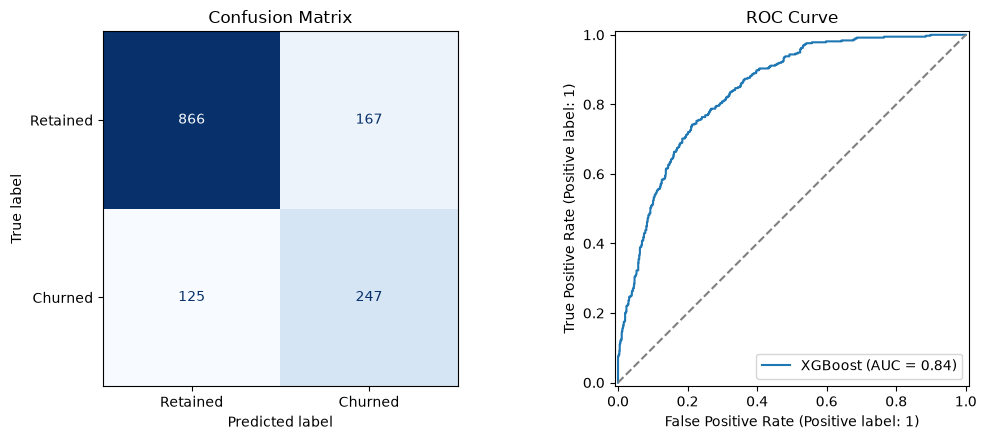

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))

cm = confusion_matrix(y_test, y_pred)
ConfusionMatrixDisplay(cm, display_labels=['Retained', 'Churned']).plot(ax=axes[0], cmap='Blues', colorbar=False)
axes[0].set_title('Confusion Matrix')

RocCurveDisplay.from_estimator(pipeline, X_test, y_test, ax=axes[1], name='XGBoost')
axes[1].plot([0, 1], [0, 1], linestyle='--', color='gray')
axes[1].set_title('ROC Curve')
plt.tight_layout()
plt.show()

## Feature importance

Gain-based feature importances from the winning XGBoost model — consistent with the EDA and statistical tests: contract type, payment method, and security/support add-ons dominate.

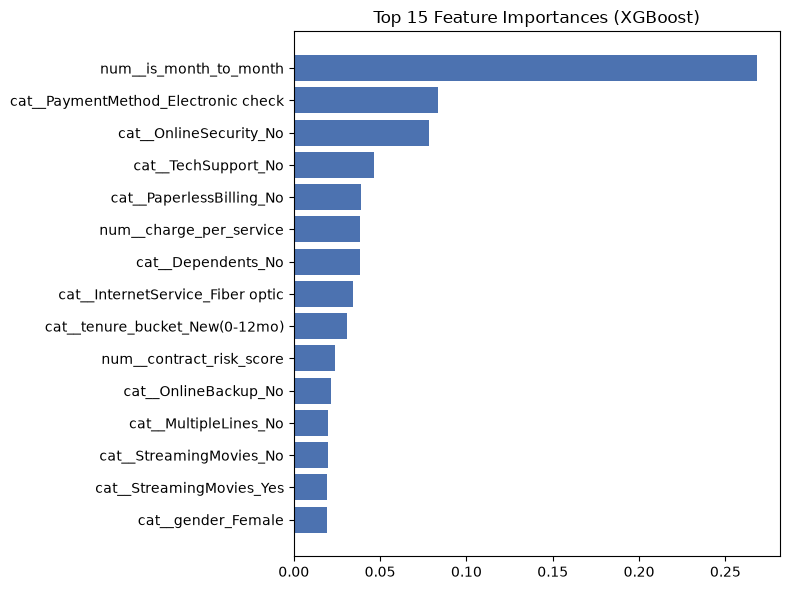

In [5]:
fi = pd.read_csv('../reports/feature_importance.csv')
fig, ax = plt.subplots(figsize=(8, 6))
ax.barh(fi['feature'][::-1], fi['importance'][::-1], color='#4C72B0')
ax.set_title('Top 15 Feature Importances (XGBoost)')
plt.tight_layout()
plt.show()

## Business takeaway

With a test-set **ROC-AUC of ~0.84**, the model reliably rank-orders customers by churn risk. Combined with the SQL insight that month-to-month, fiber-optic customers paying by electronic check churn at **~54%**, the model + segment analysis together give a retention team a concrete, prioritized target list and an estimate of monthly revenue at risk (see [`reports/sql_insights.md`](../reports/sql_insights.md)). The serialized pipeline (`models/churn_model.joblib`) is served live via the FastAPI service in [`api/main.py`](../api/main.py) and visualized in the Streamlit dashboard in [`dashboard/app.py`](../dashboard/app.py).